In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import re
import json
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import joblib
import subprocess

# Sklearn (TF-IDF ও metrics এর জন্য)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# cuDF & cuML — GPU
import cudf
# from cuml.linear_model import LogisticRegression as cuLogisticRegression

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# Install BUET Bengali Normalizer
# !pip install -q git+https://github.com/csebuetnlp/normalizer

import pandas as pd
import numpy as np
import re
import json
from bs4 import BeautifulSoup
# import emoji
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import joblib
import subprocess


# Text Normalization
# from normalizer import normalize

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

# cuDF & cuML — GPU
import cudf

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Train and Test Dataset Load

In [3]:
train_df = pd.read_excel('/content/drive/MyDrive/our-thesis-dataset-4-(80-20) (for ML)/train-thesis-4-80.xlsx')
print(train_df)

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["sentiment"])

X_train = train_df["text"]
y_train = train_df["label"]

print("Train data Label Encoded complete !!")

                                                   text sentiment
0     ভালো উদ্যোগ এই নির্দেশনাগুলো বাস্তবায়ন করতে প...  Positive
1       একটা উচ্ছিষ্ট সংগঠনকে নিষিদ্ধ করার জন্য ধন্যবাদ  Positive
2     গ্রেফতার করলে হবে না গ্রেফতার করে জনগণের হাতে ...   Neutral
3        এভাবে চলতে থাকলে দেশ উগান্ডা হতে বেশি দূরে নাই  Negative
4                               এটা প্রয়োজনীয় পদক্ষেপ  Positive
...                                                 ...       ...
4795  আমার মতে মনে হয় ট্রাফিক সিগন্যাল কেউ অমান্য ক...   Neutral
4796  এতো দিন পরে মনের মতো রাষ্ট্র প্রতিষ্ঠার চেষ্টা...  Positive
4797                সঠিক সিদ্ধান্ত ধন্যবাদ মন্ত্রীপরিষদ  Positive
4798  দেশের সম্পদ লুটপাট করে বিদেশে পাচার করাই যেন এ...  Negative
4799           বাল ফেলবে আমার ফারুকী উপদেষ্টা হয় কেমনে  Negative

[4800 rows x 2 columns]
Train data Label Encoded complete !!


In [4]:
test_df = pd.read_excel('/content/drive/MyDrive/our-thesis-dataset-4 (80-10-10) (for BERT)/test-thesis-4-10.xlsx')
print(test_df)

le = LabelEncoder()
test_df["label"] = le.fit_transform(test_df["sentiment"])

X_test = test_df["text"]
y_test = test_df["label"]

print("Test data Label Encoded complete !!")

                                                  text sentiment
0                  আয়নাঘর নির্মাণের কাজ শেষ হলো তাহলে   Neutral
1           সব শেষ করে দিয়ে আসছে পরিদর্শন করতে ঝাউড়া  Negative
2    আন্তর্জাতিক মহলে দেশের ভাবমূর্তি ক্ষুণ্ণ হচ্ছে...  Negative
3    স্যার আউটসোর্সিং কর্মচারীরা চাকরি নিয়ে আতঙ্কে...   Neutral
4    আপনার এই উদ্যোগে ভুক্তভোগী অনেক পরিবার উপকৃত হ...  Positive
..                                                 ...       ...
595         আলহামদুলিল্লাহ আমার দেশ খুব সুন্দর পথে আছে  Positive
596                      লোক দেখানো ভালবাসা দেখাবেন না  Negative
597                                  এতো দিন করনি কেনো  Negative
598        সব কয়টা পয়েন্টে সাধারণ নাগরিক হিসাবে একমত  Positive
599                           দেশ ধ্বংসের দিকে আগাচ্ছে  Negative

[600 rows x 2 columns]
Test data Label Encoded complete !!


In [5]:
print(30*"=")
print("Train Distribution:")
print("Train shape:", X_train.shape)  # ≈80%
print(y_train.value_counts())

print(30*"=")
print("\nTest Distribution:")
print("Test shape:", X_test.shape)    # 20%
print(y_test.value_counts())

Train Distribution:
Train shape: (4800,)
label
2    1600
1    1600
0    1600
Name: count, dtype: int64

Test Distribution:
Test shape: (600,)
label
1    200
0    200
2    200
Name: count, dtype: int64


In [6]:
# tfidf = TfidfVectorizer(
#     tokenizer=lambda x: x.split(),
#     token_pattern=None,
#     min_df=2, # যে শব্দগুলো অন্তত 2 বার এসেছে শুধু সেগুলোই নিবে
#     max_df=0.9 # ৯০% এর বেশি কমেন্টে যে শব্দ আছে (খুব কমন) সেগুলো বাদ দিবে
# )

def whitespace_tokenizer(text):
    return text.split()

tfidf = TfidfVectorizer(
    tokenizer=whitespace_tokenizer,
    token_pattern=None,
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

results = {}

print("TF-IDF Vectorization Complete Successfully!!")
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")
tfidf.get_feature_names_out()[:20]

TF-IDF Vectorization Complete Successfully!!
Train shape: (4800, 3647)
Test shape:  (600, 3647)


array(['অংশ', 'অংশগ্রহণ', 'অংশের', 'অকার্যকর', 'অকেজো', 'অগণতান্ত্রিক',
       'অগ্রগতি', 'অগ্রযাত্রায়', 'অগ্রসর', 'অগ্রাধিকার', 'অঙ্গ',
       'অঙ্গনে', 'অঙ্গীকার', 'অচিরেই', 'অঞ্চল', 'অঞ্চলের', 'অটো', 'অতএব',
       'অতি', 'অতিদ্রুত'], dtype=object)

✅ cuDF GPU Conversion Complete!!


# ===== Logistic Regression =====

In [ ]:
import time
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score  # optional - final test করতে চাইলে
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("Starting Logistic Regression Grid Search with tqdm...\n")

# Base model
lr_model = LogisticRegression(random_state=42)

# Valid parameter grid
lr_param_grid = [

    # L1 penalty
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.5, 1, 1.5, 2],
        'max_iter': [100, 200, 500, 1000],
        'class_weight': [None, 'balanced'],
        'fit_intercept': [True, False]
    },

    # L2 penalty
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'C': [0.5, 1, 1.5, 2],
        'max_iter': [100, 200, 500, 1000],
        'class_weight': [None, 'balanced'],
        'fit_intercept': [True, False]
    },

    # ElasticNet penalty
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'C': [0.5, 1, 1.5, 2],
        'max_iter': [100, 500, 1000, 5000],
        'class_weight': [None, 'balanced'],
        'fit_intercept': [True, False]
    }
]

# সব combination তৈরি
param_combinations = list(ParameterGrid(lr_param_grid))

total_combinations = len(param_combinations)
total_fits = total_combinations * 5   # 5-fold CV

print(f"Total parameter combinations: {total_combinations}")
print(f"Total model fits (5-fold CV): {total_fits}")

start_time = time.time()

best_score = -1
best_params = None
best_model = None

# tqdm progress bar
for params in tqdm(
    param_combinations,
    desc="Grid Search Progress",
    unit="combo",
    total=total_combinations,
    dynamic_ncols=True
):
    try:
        model = clone(lr_model)
        model.set_params(**params)

        # 5-fold CV
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,           # parallel folds
            error_score='raise'
        )
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Final fit on full train set
            best_model = clone(model).fit(X_train_tfidf, y_train)

    except Exception as e:
        print(f"Skipping combination due to error: {params}")
        print(f"Error: {e}")
        continue


end_time = time.time()
total_time_minutes = (end_time - start_time) / 60

print("\n" + "="*60)
print("Grid Search Completed!")
print(f"Best CV accuracy     : {best_score:.4f}")
print(f"Best parameters       : {best_params}")
print(f"Total time taken      : {total_time_minutes:.2f} minutes")
print("="*60)

y_train_pred = best_model.predict(X_train_tfidf)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

y_pred = best_model.predict(X_test_tfidf)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\n")
print(classification_report(y_test, y_pred))

Starting Logistic Regression Grid Search with tqdm...

Total parameter combinations: 384
Total model fits (5-fold CV): 1920


Grid Search Progress: 100%|██████████| 384/384 [06:09<00:00,  1.04combo/s]


Grid Search Completed!
Best CV accuracy     : 0.8748
Best parameters       : {'C': 1.5, 'class_weight': None, 'fit_intercept': False, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Total time taken      : 6.16 minutes
Train accuracy: 0.9585416666666666
Test accuracy: 0.86


              precision    recall  f1-score   support

           0       0.87      0.86      0.87       400
           1       0.82      0.86      0.84       400
           2       0.90      0.85      0.87       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200



In [ ]:
lr_model = LogisticRegression(C=1.5, fit_intercept= False, random_state=42)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(C=1.5, fit_intercept=False, random_state=42)





                     Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Logistic Regression         87.33          87.49       87.33         87.37





Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       200
           1       0.83      0.88      0.85       200
           2       0.92      0.87      0.89       200

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600







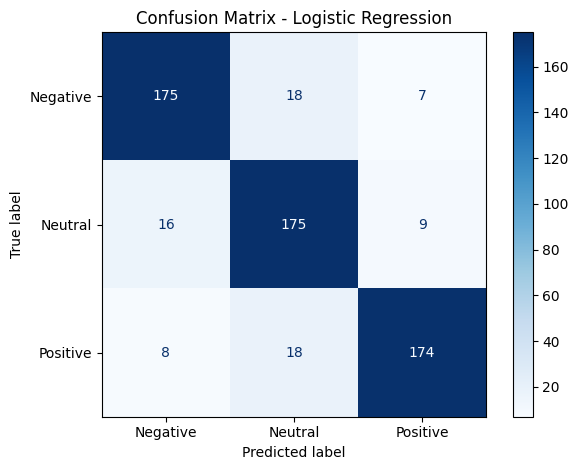

In [ ]:
lr_preds = lr_model.predict(X_test_tfidf)

results['Logistic Regression'] = {
    "Accuracy (%)": round(accuracy_score(y_test, lr_preds)*100, 2),
    "Precision (%)": round(precision_score(y_test, lr_preds, average="weighted")*100, 2),
    "Recall (%)": round(recall_score(y_test, lr_preds, average="weighted")*100, 2),
    "F1 Score (%)": round(f1_score(y_test, lr_preds, average="weighted")*100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

lr_results = pd.DataFrame([results['Logistic Regression']], index=['Logistic Regression'])
print(lr_results)

print("\n")
print(60*"=")
print(60*"=")
print("\n")

print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, lr_preds))

print("\n")
print(60*"=")
print(60*"=")
print("\n")

cm = confusion_matrix(y_test, lr_preds)

class_names = le.classes_

lr_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

lr_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()

plt.savefig("confusion_matrix_lr_8010.png", dpi=300)
# plt.savefig("confusion_matrix_lr.pdf")

plt.show()

# ===== Decision Tree =====

In [ ]:
import time
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Decision Tree-তে ConvergenceWarning নেই, তবে অন্য নয়েজ এড়াতে
warnings.filterwarnings("ignore")

print("Starting Decision Tree Grid Search with tqdm...\n")

# Base model
dt_model = DecisionTreeClassifier(random_state=42)

# Decision Tree Parameter Grid
dt_param_grid = {
    'criterion': ['entropy'],
    'max_depth': [None, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    "min_samples_split": [2, 5, 10, 20, 30, 40, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2", 0.2, 0.3, 0.5, 0.7],
    # 'class_weight': [None, 'balanced'], # because class already balanced
    'splitter': ['best', 'random']
}

# সব combination তৈরি
param_combinations = list(ParameterGrid(dt_param_grid))
total_combinations = len(param_combinations)
total_fits = total_combinations * 5   # 5-fold CV

print(f"Total parameter combinations: {total_combinations}")
print(f"Total model fits (5-fold CV): {total_fits}")

start_time = time.time()
best_score = -1
best_params = None
best_model = None

# tqdm progress bar
for params in tqdm(
    param_combinations,
    desc="Grid Search Progress",
    unit="combo",
    total=total_combinations,
    dynamic_ncols=True
):
    try:
        model = clone(dt_model)
        model.set_params(**params)

        # 5-fold CV
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,           # parallel processing
            error_score='raise'
        )
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Final fit on full train set
            best_model = clone(model).fit(X_train_tfidf, y_train)

    except Exception as e:
        print(f"Skipping combination due to error: {params}")
        print(f"Error: {e}")
        continue

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60

print("\n" + "="*60)
print("Decision Tree Grid Search Completed!")
print(f"Best CV accuracy     : {best_score:.4f}")
print(f"Best parameters       : {best_params}")
print(f"Total time taken      : {total_time_minutes:.2f} minutes")
print("="*60)

# Evaluate on train set
y_train_pred = best_model.predict(X_train_tfidf)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

# Evaluate on test set
y_pred = best_model.predict(X_test_tfidf)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Starting Decision Tree Grid Search with tqdm...

Total parameter combinations: 4900
Total model fits (5-fold CV): 24500


Grid Search Progress: 100%|██████████| 4900/4900 [31:55<00:00,  2.56combo/s]


Decision Tree Grid Search Completed!
Best CV accuracy     : 0.7471
Best parameters       : {'criterion': 'entropy', 'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 30, 'splitter': 'random'}
Total time taken      : 31.92 minutes
Train accuracy: 0.9089583333333333
Test accuracy: 0.7466666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.69      0.73       400
           1       0.68      0.78      0.73       400
           2       0.80      0.77      0.79       400

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [ ]:
dt_model = DecisionTreeClassifier(criterion= 'entropy', max_features= 0.7, min_samples_split= 30, splitter= 'random', random_state=42)

dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(criterion='entropy', max_features=0.7,
                       min_samples_split=30, random_state=42,
                       splitter='random')





               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Decision Tree          74.5          74.98        74.5         74.62





Classification Report (Decision Tree):

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       200
           1       0.67      0.75      0.71       200
           2       0.84      0.79      0.81       200

    accuracy                           0.74       600
   macro avg       0.75      0.74      0.75       600
weighted avg       0.75      0.74      0.75       600







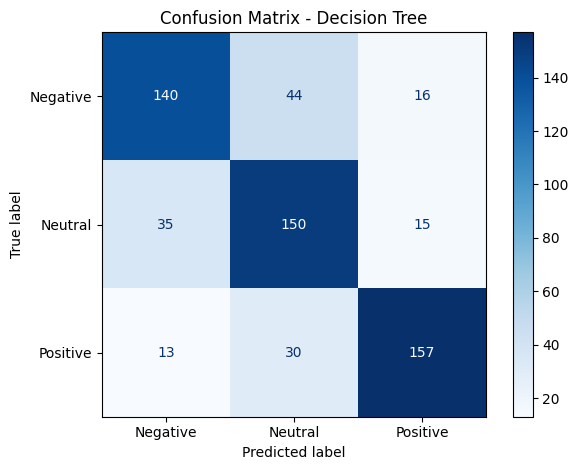

In [ ]:
dt_preds = dt_model.predict(X_test_tfidf)

results['Decision Tree'] = {
    "Accuracy (%)": round(accuracy_score(y_test, dt_preds)*100, 2),
    "Precision (%)": round(precision_score(y_test, dt_preds, average="weighted")*100, 2),
    "Recall (%)": round(recall_score(y_test, dt_preds, average="weighted")*100, 2),
    "F1 Score (%)": round(f1_score(y_test, dt_preds, average="weighted")*100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

dt_results = pd.DataFrame([results['Decision Tree']], index=['Decision Tree'])
print(dt_results)

print("\n")
print(60*"=")
print(60*"=")
print("\n")

print("\nClassification Report (Decision Tree):\n")
print(classification_report(y_test, dt_preds))

print("\n")
print(60*"=")
print(60*"=")
print("\n")

cm = confusion_matrix(y_test, dt_preds)

class_names = le.classes_

dt_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

dt_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()

plt.savefig("confusion_matrix_dt_8010.png", dpi=300)

plt.show()

# ===== Random Forest Classifier =====

In [ ]:
import time
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings("ignore")

print("Starting Random Forest Grid Search with tqdm...\n")

# Base model
rf_model = RandomForestClassifier(random_state=42)

# Random Forest Parameter Grid
# n_estimators: কতগুলো গাছ (trees) তৈরি হবে
# max_depth: প্রতিটি গাছের সর্বোচ্চ গভীরতা
# max_features: প্রতি স্প্লিটে কতগুলো ফিচার চেক করবে
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    "min_samples_leaf": [1, 2, 5],
    # 'class_weight': [None, 'balanced'], # no need because class already balanced
    # 'bootstrap': [True] # BECAUSE default value = true
}

# সব combination তৈরি
param_combinations = list(ParameterGrid(rf_param_grid))
total_combinations = len(param_combinations)
total_fits = total_combinations * 5   # 5-fold CV

print(f"Total parameter combinations: {total_combinations}")
print(f"Total model fits (5-fold CV): {total_fits}")

start_time = time.time()
best_score = -1
best_params = None
best_model = None

# tqdm progress bar
for params in tqdm(
    param_combinations,
    desc="Grid Search Progress",
    unit="combo",
    total=total_combinations,
    dynamic_ncols=True
):
    try:
        model = clone(rf_model)
        model.set_params(**params)

        # 5-fold CV
        # Random Forest-এ n_jobs=-1 ব্যবহার করলে ট্রেনিং অনেক দ্রুত হয়
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            error_score='raise'
        )
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Final fit on full train set
            best_model = model.fit(X_train_tfidf, y_train)

    except Exception as e:
        print(f"Skipping combination: {params} | Error: {e}")
        continue

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60

print("\n" + "="*60)
print("Random Forest Grid Search Completed!")
print(f"Best CV accuracy     : {best_score:.4f}")
print(f"Best parameters       : {best_params}")
print(f"Total time taken      : {total_time_minutes:.2f} minutes")
print("="*60)

# Evaluate on train set
y_train_pred = best_model.predict(X_train_tfidf)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

# Evaluate on test set
y_pred = best_model.predict(X_test_tfidf)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Starting Random Forest Grid Search with tqdm...

Total parameter combinations: 432
Total model fits (5-fold CV): 2160


Grid Search Progress: 100%|██████████| 432/432 [1:07:51<00:00,  9.43s/combo]



Random Forest Grid Search Completed!
Best CV accuracy     : 0.8567
Best parameters       : {'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Total time taken      : 67.86 minutes
Train accuracy: 0.9985416666666667
Test accuracy: 0.8616666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       400
           1       0.83      0.83      0.83       400
           2       0.89      0.87      0.88       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200



In [ ]:
rf_model = RandomForestClassifier(max_features = 'log2', min_samples_split = 5, n_estimators = 300, random_state=42)

rf_model.fit( X_train_tfidf, y_train)

RandomForestClassifier(max_features='log2', min_samples_split=5,
                       n_estimators=300, random_state=42)





               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Random Forest          87.5          87.54        87.5          87.5





Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       200
           1       0.84      0.84      0.84       200
           2       0.91      0.88      0.90       200

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600







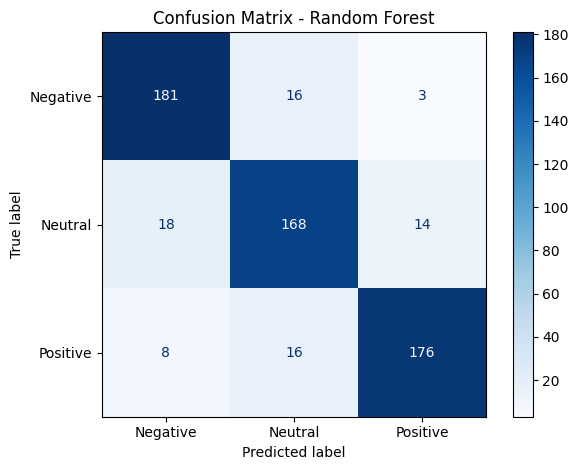

In [ ]:
rf_preds = rf_model.predict(X_test_tfidf)

results['Random Forest'] = {
    "Accuracy (%)": round(accuracy_score(y_test, rf_preds)*100, 2),
    "Precision (%)": round(precision_score(y_test, rf_preds, average="weighted")*100, 2),
    "Recall (%)": round(recall_score(y_test, rf_preds, average="weighted")*100, 2),
    "F1 Score (%)": round(f1_score(y_test, rf_preds, average="weighted")*100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

rf_results = pd.DataFrame([results['Random Forest']], index=['Random Forest'])
print(rf_results)

print("\n")
print(60*"=")
print(60*"=")
print("\n")

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, rf_preds))

print("\n")
print(60*"=")
print(60*"=")
print("\n")

cm = confusion_matrix(y_test, rf_preds)

class_names = le.classes_

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

rf_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()

plt.savefig("confusion_matrix_rf_8010.png", dpi=300)
plt.show()

# ===== Support Vector Machine Classifier = (SVM) or (SVC) =====

In [ ]:
import time
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings("ignore")

print("Starting SVC Grid Search with tqdm...\n")

# Base model
svc_model = SVC(random_state=42)

# SVC Parameter Grid
# C: Regularization parameter. ছোট মান মানে 'soft margin', বড় মান মানে 'hard margin'
# gamma: Kernel coefficient. RBF কার্নেলের জন্য এটি খুব গুরুত্বপূর্ণ
svc_param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100],
        'gamma': ['scale', 'auto', 0.0001, 0.0005, 0.001, 0.01, 0.1, 1],
        'class_weight': [None, 'balanced']
    }
]

# সব combination তৈরি
param_combinations = list(ParameterGrid(svc_param_grid))
total_combinations = len(param_combinations)
total_fits = total_combinations * 5   # 5-fold CV

print(f"Total parameter combinations: {total_combinations}")
print(f"Total model fits (5-fold CV): {total_fits}")

start_time = time.time()
best_score = -1
best_params = None
best_model = None

# tqdm progress bar
for params in tqdm(
    param_combinations,
    desc="Grid Search Progress",
    unit="combo",
    total=total_combinations,
    dynamic_ncols=True
):
    try:
        model = clone(svc_model)
        model.set_params(**params)

        # 5-fold CV
        # SVC একটু স্লো হতে পারে, তাই n_jobs=-1 ব্যবহার করা হয়েছে
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            error_score='raise'
        )
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Final fit on full train set
            best_model = model.fit(X_train_tfidf, y_train)

    except Exception as e:
        print(f"Skipping combination: {params} | Error: {e}")
        continue

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60

print("\n" + "="*60)
print("SVC Grid Search Completed!")
print(f"Best CV accuracy     : {best_score:.4f}")
print(f"Best parameters       : {best_params}")
print(f"Total time taken      : {total_time_minutes:.2f} minutes")
print("="*60)

# Evaluate on train set
y_train_pred = best_model.predict(X_train_tfidf)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

# Evaluate on test set
y_pred = best_model.predict(X_test_tfidf)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Starting SVC Grid Search with tqdm...

Total parameter combinations: 180
Total model fits (5-fold CV): 900


Grid Search Progress: 100%|██████████| 180/180 [38:32<00:00, 12.85s/combo]



SVC Grid Search Completed!
Best CV accuracy     : 0.8819
Best parameters       : {'C': 2, 'class_weight': None, 'gamma': 1, 'kernel': 'rbf'}
Total time taken      : 38.55 minutes
Train accuracy: 0.998125
Test accuracy: 0.8733333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       400
           1       0.81      0.88      0.84       400
           2       0.94      0.86      0.90       400

    accuracy                           0.87      1200
   macro avg       0.88      0.87      0.87      1200
weighted avg       0.88      0.87      0.87      1200



In [ ]:
svc_model = SVC(C = 2, gamma=1, random_state=42)

svc_model.fit(X_train_tfidf, y_train)

SVC(C=2, gamma=1, random_state=42)





                        Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Support Vector Machine         88.83          89.28       88.83         88.92





Classification Report (Support Vector Machine):

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       200
           1       0.83      0.90      0.86       200
           2       0.97      0.87      0.92       200

    accuracy                           0.89       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.89      0.89      0.89       600







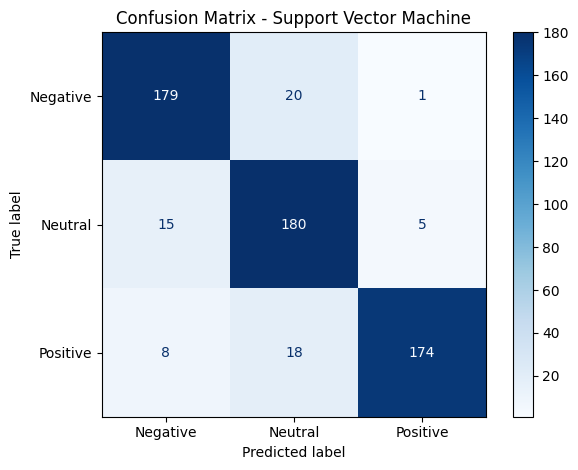

In [ ]:
svc_preds = svc_model.predict(X_test_tfidf)

results['Support Vector Machine'] = {
    "Accuracy (%)": round(accuracy_score(y_test, svc_preds)*100, 2),
    "Precision (%)": round(precision_score(y_test, svc_preds, average="weighted")*100, 2),
    "Recall (%)": round(recall_score(y_test, svc_preds, average="weighted")*100, 2),
    "F1 Score (%)": round(f1_score(y_test, svc_preds, average="weighted")*100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

svc_results = pd.DataFrame([results['Support Vector Machine']], index=['Support Vector Machine'])
print(svc_results)

print("\n")
print(60*"=")
print(60*"=")
print("\n")

print("\nClassification Report (Support Vector Machine):\n")
print(classification_report(y_test, svc_preds))

print("\n")
print(60*"=")
print(60*"=")
print("\n")

cm = confusion_matrix(y_test, svc_preds)

class_names = le.classes_

svc_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

svc_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Support Vector Machine")
plt.tight_layout()

plt.savefig("confusion_matrix_svm_8010.png", dpi=300)
plt.show()

# ===== Naive Bayes =====

In [ ]:
import time
from tqdm import tqdm
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import warnings

warnings.filterwarnings("ignore")

print("Starting Multinomial Naive Bayes Grid Search with tqdm...\n")

# Base model
nb_model = MultinomialNB()

# default Parameters
# multinomial_nb_default_params = {
#     "alpha": 1.0,
#     "fit_prior": True,
#     "class_prior": None,
#     "force_alpha": True
# }

# Naive Bayes Parameter Grid
# alpha: ০ হলে smoothing হবে না, ১ হলো Laplace smoothing।
# টেক্সট ডাটার জন্য সাধারণত ছোট মান (০.০১ - ১.০) ভালো কাজ করে।
nb_param_grid = {
    "alpha": [
        0.0001, 0.001, 0.01, 0.1,
        0.2, 0.5, 0.8, 1.0, 1.5,
        2.0, 3.0, 5.0, 8.0, 10.0
    ],
    "fit_prior": [True, False],
    'force_alpha': [True, False],
    "class_prior": [
        None, 'balanced', [0.33, 0.33, 0.34]
    ]
}

# সব combination তৈরি
param_combinations = list(ParameterGrid(nb_param_grid))
total_combinations = len(param_combinations)
total_fits = total_combinations * 5   # 5-fold CV

print(f"Total parameter combinations: {total_combinations}")
print(f"Total model fits (5-fold CV): {total_fits}")

start_time = time.time()
best_score = -1
best_params = None
best_model = None

# tqdm progress bar
for params in tqdm(
    param_combinations,
    desc="Grid Search Progress",
    unit="combo",
    total=total_combinations,
    dynamic_ncols=True
):
    try:
        model = clone(nb_model)
        model.set_params(**params)

        # 5-fold CV
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=5,
            scoring='accuracy',
            n_jobs=-1,           # parallel processing
            error_score='raise'
        )
        mean_score = scores.mean()

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Final fit on full train set
            best_model = model.fit(X_train_tfidf, y_train)

    except Exception as e:
        print(f"Skipping combination: {params} | Error: {e}")
        continue

end_time = time.time()
total_time_minutes = (end_time - start_time) / 60

print("\n" + "="*60)
print("Naive Bayes Grid Search Completed!")
print(f"Best CV accuracy     : {best_score:.4f}")
print(f"Best parameters       : {best_params}")
print(f"Total time taken      : {total_time_minutes:.2f} minutes")
print("="*60)

# Evaluate on train set
y_train_pred = best_model.predict(X_train_tfidf)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

# Evaluate on test set
y_pred = best_model.predict(X_test_tfidf)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Starting Multinomial Naive Bayes Grid Search with tqdm...

Total parameter combinations: 168
Total model fits (5-fold CV): 840


Grid Search Progress:   2%|▏         | 4/168 [00:02<01:28,  1.85combo/s]

Skipping combination: {'alpha': 0.0001, 'class_prior': 'balanced', 'fit_prior': True, 'force_alpha': True} | Error: The 'class_prior' parameter of cross_val_score must be an array-like or None. Got 'balanced' instead.


Grid Search Progress:   4%|▎         | 6/168 [00:04<02:06,  1.28combo/s]

Skipping combination: {'alpha': 0.0001, 'class_prior': 'balanced', 'fit_prior': True, 'force_alpha': False} | Error: The 'class_prior' parameter of cross_val_score must be an array-like or None. Got 'balanced' instead.


...

Skipping combination: {'alpha': 10.0, 'class_prior': 'balanced', 'fit_prior': True, 'force_alpha': False} | Error: The 'class_prior' parameter of cross_val_score must be an array-like or None. Got 'balanced' instead.
Skipping combination: {'alpha': 10.0, 'class_prior': 'balanced', 'fit_prior': False, 'force_alpha': True} | Error: The 'class_prior' parameter of cross_val_score must be an array-like or None. Got 'balanced' instead.


Grid Search Progress:  98%|█████████▊| 164/168 [02:29<00:04,  1.03s/combo]

Skipping combination: {'alpha': 10.0, 'class_prior': 'balanced', 'fit_prior': False, 'force_alpha': False} | Error: The 'class_prior' parameter of cross_val_score must be an array-like or None. Got 'balanced' instead.


Grid Search Progress: 100%|██████████| 168/168 [02:31<00:00,  1.11combo/s]



Naive Bayes Grid Search Completed!
Best CV accuracy     : 0.8640
Best parameters       : {'alpha': 0.8, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}
Total time taken      : 2.53 minutes
Train accuracy: 0.9308333333333333
Test accuracy: 0.8575

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.83      0.87       400
           1       0.80      0.87      0.83       400
           2       0.88      0.87      0.88       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200



In [ ]:
mnb_model = MultinomialNB(alpha = 0.8, force_alpha=True)

mnb_model.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.8)





                         Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Multinomial Naïve Bayes         86.17          86.55       86.17         86.21





Classification Report (Multinomial Naïve Bayes):

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       200
           1       0.80      0.88      0.84       200
           2       0.87      0.89      0.88       200

    accuracy                           0.86       600
   macro avg       0.87      0.86      0.86       600
weighted avg       0.87      0.86      0.86       600







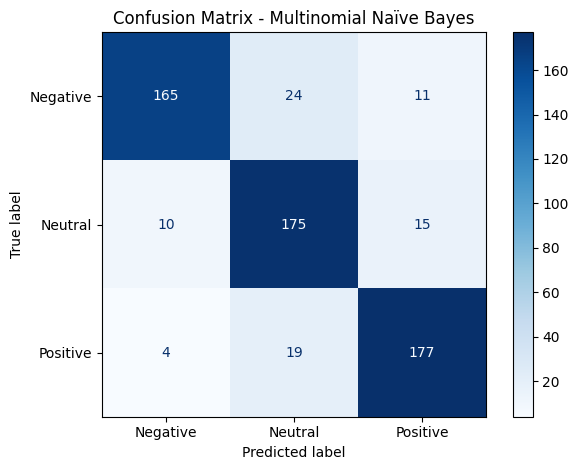

In [ ]:
mnb_preds = mnb_model.predict(X_test_tfidf)

results['Multinomial Naïve Bayes'] = {
    "Accuracy (%)": round(accuracy_score(y_test, mnb_preds)*100, 2),
    "Precision (%)": round(precision_score(y_test, mnb_preds, average="weighted")*100, 2),
    "Recall (%)": round(recall_score(y_test, mnb_preds, average="weighted")*100, 2),
    "F1 Score (%)": round(f1_score(y_test, mnb_preds, average="weighted")*100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

mnb_results = pd.DataFrame([results['Multinomial Naïve Bayes']], index=['Multinomial Naïve Bayes'])
print(mnb_results)

print("\n")
print(60*"=")
print(60*"=")
print("\n")

print("\nClassification Report (Multinomial Naïve Bayes):\n")
print(classification_report(y_test, mnb_preds))

print("\n")
print(60*"=")
print(60*"=")
print("\n")

cm = confusion_matrix(y_test, mnb_preds)

class_names = le.classes_

mnb_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

mnb_disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Multinomial Naïve Bayes")
plt.tight_layout()

plt.savefig("confusion_matrix_mnb_8010.png", dpi=300)
plt.show()

# ⏰TIME Complexity Calculation:-

## LR

In [17]:
# # =========================
# # Logistic Regression Model
# # =========================

# lr_model = LogisticRegression(
#     C=1.5,
#     fit_intercept=False,
#     random_state=42
# )

# process = psutil.Process(os.getpid())

# # =========================
# # Training Time & Memory
# # =========================

# memory_before = process.memory_info().rss / (1024 ** 2)

# train_start = time.time()
# lr_model.fit(X_train_tfidf, y_train)
# train_end = time.time()

# memory_after = process.memory_info().rss / (1024 ** 2)

# training_time = train_end - train_start
# memory_usage = memory_after - memory_before

# print(f"Training Time: {training_time:.4f} seconds")
# print(f"Memory Usage: {memory_usage:.4f} MB")

# # =========================
# # Inference Time & Throughput
# # =========================

# infer_start = time.time()
# lr_preds = lr_model.predict(X_test_tfidf)
# infer_end = time.time()

# total_inference_time = infer_end - infer_start
# inference_time_ms = (total_inference_time / len(X_test)) * 1000
# throughput = len(X_test) / total_inference_time

# print(f"Total Inference Time: {total_inference_time:.4f} seconds")
# print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
# print(f"Throughput: {throughput:.4f} samples/s")

# # =========================
# # Model Size
# # =========================

# model_package = {
#     "tfidf": tfidf,
#     "model": lr_model,
#     "label_encoder": le
# }

# joblib.dump(model_package, "logistic_regression_tfidf_model.pkl")

# model_size = os.path.getsize("logistic_regression_tfidf_model.pkl") / (1024 ** 2)

# print(f"Model Size: {model_size:.4f} MB")

# # =========================
# # Performance Result
# # =========================

# results = {}

# results["Logistic Regression"] = {
#     "Accuracy (%)": round(accuracy_score(y_test, lr_preds) * 100, 2),
#     "Precision (%)": round(precision_score(y_test, lr_preds, average="weighted") * 100, 2),
#     "Recall (%)": round(recall_score(y_test, lr_preds, average="weighted") * 100, 2),
#     "F1 Score (%)": round(f1_score(y_test, lr_preds, average="weighted") * 100, 2)
# }

# lr_results = pd.DataFrame(
#     [results["Logistic Regression"]],
#     index=["Logistic Regression"]
# )

# print("\nPerformance Result:")
# print(lr_results)

# # =========================
# # Computational Complexity Result
# # =========================

# complexity_results = {}

# complexity_results["Logistic Regression"] = {
#     "Training Time (s)": round(training_time, 4),
#     "Inference Time (ms/sample)": round(inference_time_ms, 4),
#     "Throughput (samples/s)": round(throughput, 4),
#     "Memory Usage (MB)": round(memory_usage, 4),
#     "Model Size (MB)": round(model_size, 4)
# }

# lr_complexity_df = pd.DataFrame(
#     [complexity_results["Logistic Regression"]],
#     index=["Logistic Regression"]
# )

# print("\nComputational Complexity Result:")
# print(lr_complexity_df)

Training Time: 0.4150 seconds
Memory Usage: 0.0000 MB
Total Inference Time: 0.0048 seconds
Inference Time: 0.0080 ms/sample
Throughput: 125452.7617 samples/s
Model Size: 0.1987 MB

Performance Result:
                     Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Logistic Regression         87.33          87.49       87.33         87.37

Computational Complexity Result:
                     Training Time (s)  Inference Time (ms/sample)  \
Logistic Regression              0.415                       0.008   

                     Throughput (samples/s)  Memory Usage (MB)  \
Logistic Regression             125452.7617                0.0   

                     Model Size (MB)  
Logistic Regression           0.1987  


In [13]:
# =========================
# Logistic Regression Model
# =========================

from cuml.linear_model import LogisticRegression as cuLogisticRegression

lr_model = cuLogisticRegression(
    C=1.5,
    fit_intercept=False
)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())


# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")


# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
lr_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start = time.time()
lr_preds_gpu = lr_model.predict(X_test_cudf)
lr_preds     = lr_preds_gpu.to_numpy()   # metrics এর জন্য numpy-তে আনো
infer_end = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": lr_model,
    "label_encoder": le
}

joblib.dump(model_package, "logistic_regression_tfidf_model.pkl")

model_size = os.path.getsize("logistic_regression_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Performance Result
# =========================

results = {}

results["Logistic Regression"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, lr_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, lr_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, lr_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, lr_preds, average="weighted") * 100, 2)
}

lr_results = pd.DataFrame(
    [results["Logistic Regression"]],
    index=["Logistic Regression"]
)

print("\nPerformance Result:")
print(lr_results)

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Logistic Regression"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

lr_complexity_df = pd.DataFrame(
    [complexity_results["Logistic Regression"]],   # ← সঠিক
    index=["Logistic Regression"]
)

print("\nComputational Complexity Result:")
print(lr_complexity_df)

Training Time: 2.2893 seconds
GPU Memory Usage: 10.0000 MB
Total Inference Time: 1.2577 seconds
Inference Time: 2.0961 ms/sample
Throughput: 477.0765 samples/s
Model Size: 0.1577 MB

Performance Result:
                     Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Logistic Regression         86.83          86.95       86.83         86.86

Computational Complexity Result:
                     Training Time (s)  Inference Time (ms/sample)  \
Logistic Regression             2.2893                      2.0961   

                     Throughput (samples/s)  Memory Usage (MB)  \
Logistic Regression                477.0765               10.0   

                     Model Size (MB)  
Logistic Regression           0.1577  


## DT

In [ ]:
# # =========================
# # Decision Tree Model
# # =========================

# dt_model = DecisionTreeClassifier(
#     criterion='entropy',
#     max_features=0.7,
#     min_samples_split=30,
#     splitter='random',
#     random_state=42
# )

# process = psutil.Process(os.getpid())

# # =========================
# # Training Time & Memory
# # =========================

# memory_before = process.memory_info().rss / (1024 ** 2)

# train_start = time.time()
# dt_model.fit(X_train_tfidf, y_train)
# train_end = time.time()

# memory_after = process.memory_info().rss / (1024 ** 2)

# training_time = train_end - train_start
# memory_usage = memory_after - memory_before

# print(f"Training Time: {training_time:.4f} seconds")
# print(f"Memory Usage: {memory_usage:.4f} MB")

# # =========================
# # Inference Time & Throughput
# # =========================

# infer_start = time.time()
# dt_preds = dt_model.predict(X_test_tfidf)
# infer_end = time.time()

# total_inference_time = infer_end - infer_start
# inference_time_ms = (total_inference_time / len(X_test)) * 1000
# throughput = len(X_test) / total_inference_time

# print(f"Total Inference Time: {total_inference_time:.4f} seconds")
# print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
# print(f"Throughput: {throughput:.4f} samples/s")

# # =========================
# # Model Size
# # =========================

# model_package = {
#     "tfidf": tfidf,
#     "model": dt_model,
#     "label_encoder": le
# }

# joblib.dump(model_package, "decision_tree_tfidf_model.pkl")

# model_size = os.path.getsize("decision_tree_tfidf_model.pkl") / (1024 ** 2)

# print(f"Model Size: {model_size:.4f} MB")

# # =========================
# # Performance Result
# # =========================

# results = {}

# results["Decision Tree"] = {
#     "Accuracy (%)": round(accuracy_score(y_test, dt_preds) * 100, 2),
#     "Precision (%)": round(precision_score(y_test, dt_preds, average="weighted") * 100, 2),
#     "Recall (%)": round(recall_score(y_test, dt_preds, average="weighted") * 100, 2),
#     "F1 Score (%)": round(f1_score(y_test, dt_preds, average="weighted") * 100, 2)
# }

# dt_results = pd.DataFrame(
#     [results["Decision Tree"]],
#     index=["Decision Tree"]
# )

# print("\nPerformance Result:")
# print(dt_results)

# # =========================
# # Computational Complexity Result
# # =========================

# complexity_results = {}

# complexity_results["Decision Tree"] = {
#     "Training Time (s)": round(training_time, 4),
#     "Inference Time (ms/sample)": round(inference_time_ms, 4),
#     "Throughput (samples/s)": round(throughput, 4),
#     "Memory Usage (MB)": round(memory_usage, 4),
#     "Model Size (MB)": round(model_size, 4)
# }

# dt_complexity_df = pd.DataFrame(
#     [complexity_results["Decision Tree"]],
#     index=["Decision Tree"]
# )

# print("\nComputational Complexity Result:")
# print(dt_complexity_df)


Training Time: 0.2787 seconds
Memory Usage: 0.2617 MB
Total Inference Time: 0.0011 seconds
Inference Time: 0.0019 ms/sample
Throughput: 523524.5267 samples/s
Model Size: 0.2226 MB

Performance Result:
               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Decision Tree          74.5          74.98        74.5         74.62

Computational Complexity Result:
               Training Time (s)  Inference Time (ms/sample)  \
Decision Tree             0.2787                      0.0019   

               Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
Decision Tree             523524.5267             0.2617           0.2226  


In [8]:
# =========================
# Decision Tree Model (GPU)
# cuML এ standalone DT নেই, তাই RandomForest দিয়ে
# n_estimators=1 করলে essentially একটাই Decision Tree
# =========================

from cuml.ensemble import RandomForestClassifier as cuDecisionTreeClassifier

dt_model = cuDecisionTreeClassifier(
    n_estimators=1,          # একটাই tree = Decision Tree
    criterion='entropy',
    max_features=0.7,
    min_samples_split=30,
    random_state=42
)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())

# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")

# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
dt_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start  = time.time()
dt_preds_gpu = dt_model.predict(X_test_cudf)
dt_preds     = dt_preds_gpu.to_numpy().astype('int32')
infer_end    = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": dt_model,
    "label_encoder": le
}

joblib.dump(model_package, "decision_tree_tfidf_model.pkl")

model_size = os.path.getsize("decision_tree_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Performance Result
# =========================

results = {}

results["Decision Tree"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, dt_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, dt_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, dt_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, dt_preds, average="weighted") * 100, 2)
}

dt_results = pd.DataFrame(
    [results["Decision Tree"]],
    index=["Decision Tree"]
)

print("\nPerformance Result:")
print(dt_results)

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Decision Tree"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

dt_complexity_df = pd.DataFrame(
    [complexity_results["Decision Tree"]],
    index=["Decision Tree"]
)

print("\nComputational Complexity Result:")
print(dt_complexity_df)

✅ Data moved to GPU!
Training Time: 1.3847 seconds
GPU Memory Usage: 2.0000 MB
Total Inference Time: 0.4334 seconds
Inference Time: 0.7224 ms/sample
Throughput: 1384.3577 samples/s
Model Size: 0.1489 MB

Performance Result:
               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Decision Tree         65.67          71.36       65.67         65.44

Computational Complexity Result:
               Training Time (s)  Inference Time (ms/sample)  \
Decision Tree             1.3847                      0.7224   

               Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
Decision Tree               1384.3577                2.0           0.1489  


## RF

In [ ]:
# # =========================
# # Random Forest Model
# # =========================

# rf_model = RandomForestClassifier(
#     max_features='log2',
#     min_samples_split=5,
#     n_estimators=300,
#     random_state=42
# )

# process = psutil.Process(os.getpid())

# # =========================
# # Training Time & Memory
# # =========================

# memory_before = process.memory_info().rss / (1024 ** 2)

# train_start = time.time()
# rf_model.fit(X_train_tfidf, y_train)
# train_end = time.time()

# memory_after = process.memory_info().rss / (1024 ** 2)

# training_time = train_end - train_start
# memory_usage = memory_after - memory_before

# print(f"Training Time: {training_time:.4f} seconds")
# print(f"Memory Usage: {memory_usage:.4f} MB")

# # =========================
# # Inference Time & Throughput
# # =========================

# infer_start = time.time()
# rf_preds = rf_model.predict(X_test_tfidf)
# infer_end = time.time()

# total_inference_time = infer_end - infer_start
# inference_time_ms = (total_inference_time / len(X_test)) * 1000
# throughput = len(X_test) / total_inference_time

# print(f"Total Inference Time: {total_inference_time:.4f} seconds")
# print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
# print(f"Throughput: {throughput:.4f} samples/s")

# # =========================
# # Model Size
# # =========================

# model_package = {
#     "tfidf": tfidf,
#     "model": rf_model,
#     "label_encoder": le
# }

# joblib.dump(model_package, "random_forest_tfidf_model.pkl")

# model_size = os.path.getsize("random_forest_tfidf_model.pkl") / (1024 ** 2)

# print(f"Model Size: {model_size:.4f} MB")

# # =========================
# # Performance Result
# # =========================

# results = {}

# results["Random Forest"] = {
#     "Accuracy (%)": round(accuracy_score(y_test, rf_preds) * 100, 2),
#     "Precision (%)": round(precision_score(y_test, rf_preds, average="weighted") * 100, 2),
#     "Recall (%)": round(recall_score(y_test, rf_preds, average="weighted") * 100, 2),
#     "F1 Score (%)": round(f1_score(y_test, rf_preds, average="weighted") * 100, 2)
# }

# rf_results = pd.DataFrame(
#     [results["Random Forest"]],
#     index=["Random Forest"]
# )

# print("\nPerformance Result:")
# print(rf_results)

# # =========================
# # Computational Complexity Result
# # =========================

# complexity_results = {}

# complexity_results["Random Forest"] = {
#     "Training Time (s)": round(training_time, 4),
#     "Inference Time (ms/sample)": round(inference_time_ms, 4),
#     "Throughput (samples/s)": round(throughput, 4),
#     "Memory Usage (MB)": round(memory_usage, 4),
#     "Model Size (MB)": round(model_size, 4)
# }

# rf_complexity_df = pd.DataFrame(
#     [complexity_results["Random Forest"]],
#     index=["Random Forest"]
# )

# print("\nComputational Complexity Result:")
# print(rf_complexity_df)

Training Time: 11.4991 seconds
Memory Usage: 95.9688 MB
Total Inference Time: 0.1422 seconds
Inference Time: 0.2371 ms/sample
Throughput: 4218.1082 samples/s
Model Size: 87.5604 MB

Performance Result:
               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Random Forest          87.5          87.54        87.5          87.5

Computational Complexity Result:
               Training Time (s)  Inference Time (ms/sample)  \
Random Forest            11.4991                      0.2371   

               Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
Random Forest               4218.1082            95.9688          87.5604  


In [8]:
# =========================
# Random Forest Model (GPU)
# =========================

from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier

rf_model = cuRandomForestClassifier(
    max_features='log2',
    min_samples_split=5,
    n_estimators=300,
    random_state=42
)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())

# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")

# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
rf_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start  = time.time()
rf_preds_gpu = rf_model.predict(X_test_cudf)
rf_preds     = rf_preds_gpu.to_numpy().astype('int32')
infer_end    = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": rf_model,
    "label_encoder": le
}

joblib.dump(model_package, "random_forest_tfidf_model.pkl")

model_size = os.path.getsize("random_forest_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Performance Result
# =========================

results = {}

results["Random Forest"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, rf_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, rf_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, rf_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, rf_preds, average="weighted") * 100, 2)
}

rf_results = pd.DataFrame(
    [results["Random Forest"]],
    index=["Random Forest"]
)

print("\nPerformance Result:")
print(rf_results)

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Random Forest"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

rf_complexity_df = pd.DataFrame(
    [complexity_results["Random Forest"]],
    index=["Random Forest"]
)

print("\nComputational Complexity Result:")
print(rf_complexity_df)

✅ Data moved to GPU!
Training Time: 2.0431 seconds
GPU Memory Usage: 2.0000 MB
Total Inference Time: 0.4471 seconds
Inference Time: 0.7452 ms/sample
Throughput: 1341.9318 samples/s
Model Size: 1.3552 MB

Performance Result:
               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Random Forest         81.83          82.08       81.83         81.88

Computational Complexity Result:
               Training Time (s)  Inference Time (ms/sample)  \
Random Forest             2.0431                      0.7452   

               Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
Random Forest               1341.9318                2.0           1.3552  


In [9]:
# =========================
# Random Forest Model (GPU)
# =========================

import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier
from cuml import using_output_type

rf_model = cuRandomForestClassifier(
    max_features='log2',
    min_samples_split=5,
    n_estimators=300,
    random_state=42,
    max_depth=100,   # ← Changed from None to 100 to fix TypeError
    n_bins=256        # ← এটাও যোগ করো, বেশি bins = বেশি accurate split
)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())

# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")

# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
with using_output_type('numpy'):
    rf_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start = time.time()
with using_output_type('numpy'):
    rf_preds = rf_model.predict(X_test_cudf).astype('int32')
infer_end = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": rf_model,
    "label_encoder": le
}

joblib.dump(model_package, "random_forest_tfidf_model.pkl")

model_size = os.path.getsize("random_forest_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Performance Result
# =========================

results = {}

results["Random Forest"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, rf_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, rf_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, rf_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, rf_preds, average="weighted") * 100, 2)
}

rf_results = pd.DataFrame(
    [results["Random Forest"]],
    index=["Random Forest"]
)

print("\nPerformance Result:")
print(rf_results)

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Random Forest"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

rf_complexity_df = pd.DataFrame(
    [complexity_results["Random Forest"]],
    index=["Random Forest"]
)

print("\nComputational Complexity Result:")
print(rf_complexity_df)

✅ Data moved to GPU!
Training Time: 2.6405 seconds
GPU Memory Usage: 0.0000 MB
Total Inference Time: 0.4280 seconds
Inference Time: 0.7133 ms/sample
Throughput: 1401.8888 samples/s
Model Size: 6.6108 MB

Performance Result:
               Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Random Forest         84.67          84.81       84.67         84.71

Computational Complexity Result:
               Training Time (s)  Inference Time (ms/sample)  \
Random Forest             2.6405                      0.7133   

               Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
Random Forest               1401.8888                0.0           6.6108  


## SVC

In [ ]:
# svc_model = SVC(C=2, gamma=1, random_state=42)

# process = psutil.Process(os.getpid())

# memory_before = process.memory_info().rss / (1024 ** 2)

# train_start = time.time()
# svc_model.fit(X_train_tfidf, y_train)
# train_end = time.time()

# memory_after = process.memory_info().rss / (1024 ** 2)

# training_time = train_end - train_start
# memory_usage = memory_after - memory_before

# print(f"Training Time: {training_time:.4f} seconds")
# print(f"Memory Usage: {memory_usage:.4f} MB")

Training Time: 3.3253 seconds
Memory Usage: 0.1094 MB


In [ ]:
# # ==============================================================
# # Inference time and throughput
# # ==============================================================
# infer_start = time.time()
# svc_preds = svc_model.predict(X_test_tfidf)
# infer_end = time.time()

# total_inference_time = infer_end - infer_start
# inference_time_ms = (total_inference_time / len(X_test)) * 1000
# throughput = len(X_test) / total_inference_time

# print(f"Total Inference Time: {total_inference_time:.4f} seconds")
# print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
# print(f"Throughput: {throughput:.4f} samples/s")

# # ========================
# # Model size
# # ========================
# model_package = {
#     "tfidf": tfidf,
#     "model": svc_model,
#     "label_encoder": le
# }

# joblib.dump(model_package, "svm_tfidf_model.pkl")
# model_size = os.path.getsize("svm_tfidf_model.pkl") / (1024 ** 2)

# print(f"Model Size: {model_size:.4f} MB")

# # ==============================================================
# # Computational complexity result
# # ==============================================================
# complexity_results = {}

# complexity_results["Support Vector Machine"] = {
#     "Training Time (s)": round(training_time, 4),
#     "Inference Time (ms/sample)": round(inference_time_ms, 4),
#     "Throughput (samples/s)": round(throughput, 4),
#     "Memory Usage (MB)": round(memory_usage, 4),
#     "Model Size (MB)": round(model_size, 4)
# }

# svc_complexity_df = pd.DataFrame(
#     [complexity_results["Support Vector Machine"]],
#     index=["Support Vector Machine"]
# )

# print("\nComputational Complexity Result:")
# print(svc_complexity_df)

# # ===========================================================
# # ===========================================================

# results['Support Vector Machine'] = {
#     "Accuracy (%)": round(accuracy_score(y_test, svc_preds)*100, 2),
#     "Precision (%)": round(precision_score(y_test, svc_preds, average="weighted")*100, 2),
#     "Recall (%)": round(recall_score(y_test, svc_preds, average="weighted")*100, 2),
#     "F1 Score (%)": round(f1_score(y_test, svc_preds, average="weighted")*100, 2)
# }

# print("\n")
# print(60*"=")
# print(60*"=")
# print("\n")

# svc_results = pd.DataFrame([results['Support Vector Machine']], index=['Support Vector Machine'])
# print(svc_results)

Total Inference Time: 0.2355 seconds
Inference Time: 0.3925 ms/sample
Throughput: 2547.7593 samples/s
Model Size: 0.6922 MB

Computational Complexity Result:
                        Training Time (s)  Inference Time (ms/sample)  \
Support Vector Machine             3.3253                      0.3925   

                        Throughput (samples/s)  Memory Usage (MB)  \
Support Vector Machine               2547.7593             0.1094   

                        Model Size (MB)  
Support Vector Machine           0.6922  




                        Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Support Vector Machine         88.83          89.28       88.83         88.92


In [8]:
# =========================
# Support Vector Machine Model (GPU)
# =========================

from cuml.svm import SVC as cuSVC

svc_model = cuSVC(
    C=2,
    gamma=1
)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())

# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")

# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
svc_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start   = time.time()
svc_preds_gpu = svc_model.predict(X_test_cudf)
svc_preds     = svc_preds_gpu.to_numpy().astype('int32')
infer_end     = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": svc_model,
    "label_encoder": le
}

joblib.dump(model_package, "svm_tfidf_model.pkl")

model_size = os.path.getsize("svm_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Support Vector Machine"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

svc_complexity_df = pd.DataFrame(
    [complexity_results["Support Vector Machine"]],
    index=["Support Vector Machine"]
)

print("\nComputational Complexity Result:")
print(svc_complexity_df)

# =========================
# Performance Result
# =========================

results = {}

results["Support Vector Machine"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, svc_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, svc_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, svc_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, svc_preds, average="weighted") * 100, 2)
}

print("\n")
print(60*"=")
print(60*"=")
print("\n")

svc_results = pd.DataFrame(
    [results["Support Vector Machine"]],
    index=["Support Vector Machine"]
)

print(svc_results)

✅ Data moved to GPU!
Training Time: 4.4952 seconds
GPU Memory Usage: 112.0000 MB
Total Inference Time: 0.4945 seconds
Inference Time: 0.8242 ms/sample
Throughput: 1213.2639 samples/s
Model Size: 97.8226 MB

Computational Complexity Result:
                        Training Time (s)  Inference Time (ms/sample)  \
Support Vector Machine             4.4952                      0.8242   

                        Throughput (samples/s)  Memory Usage (MB)  \
Support Vector Machine               1213.2639              112.0   

                        Model Size (MB)  
Support Vector Machine          97.8226  




                        Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Support Vector Machine         88.83          89.25       88.83         88.91


## MNB

In [ ]:
# # =========================
# # Multinomial Naïve Bayes Model
# # =========================

# mnb_model = MultinomialNB(
#     alpha=0.8,
#     force_alpha=True
# )

# process = psutil.Process(os.getpid())

# # =========================
# # Training Time & Memory
# # =========================

# memory_before = process.memory_info().rss / (1024 ** 2)

# train_start = time.time()
# mnb_model.fit(X_train_tfidf, y_train)
# train_end = time.time()

# memory_after = process.memory_info().rss / (1024 ** 2)

# training_time = train_end - train_start
# memory_usage = memory_after - memory_before

# print(f"Training Time: {training_time:.4f} seconds")
# print(f"Memory Usage: {memory_usage:.4f} MB")

# # =========================
# # Inference Time & Throughput
# # =========================

# infer_start = time.time()
# mnb_preds = mnb_model.predict(X_test_tfidf)
# infer_end = time.time()

# total_inference_time = infer_end - infer_start
# inference_time_ms = (total_inference_time / len(X_test)) * 1000
# throughput = len(X_test) / total_inference_time

# print(f"Total Inference Time: {total_inference_time:.4f} seconds")
# print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
# print(f"Throughput: {throughput:.4f} samples/s")

# # =========================
# # Model Size
# # =========================

# model_package = {
#     "tfidf": tfidf,
#     "model": mnb_model,
#     "label_encoder": le
# }

# joblib.dump(model_package, "multinomial_nb_tfidf_model.pkl")

# model_size = os.path.getsize("multinomial_nb_tfidf_model.pkl") / (1024 ** 2)

# print(f"Model Size: {model_size:.4f} MB")

# # =========================
# # Performance Result
# # =========================

# results = {}

# results["Multinomial Naïve Bayes"] = {
#     "Accuracy (%)": round(accuracy_score(y_test, mnb_preds) * 100, 2),
#     "Precision (%)": round(precision_score(y_test, mnb_preds, average="weighted") * 100, 2),
#     "Recall (%)": round(recall_score(y_test, mnb_preds, average="weighted") * 100, 2),
#     "F1 Score (%)": round(f1_score(y_test, mnb_preds, average="weighted") * 100, 2)
# }

# mnb_results = pd.DataFrame(
#     [results["Multinomial Naïve Bayes"]],
#     index=["Multinomial Naïve Bayes"]
# )

# print("\nPerformance Result:")
# print(mnb_results)

# # =========================
# # Computational Complexity Result
# # =========================

# complexity_results = {}

# complexity_results["Multinomial Naïve Bayes"] = {
#     "Training Time (s)": round(training_time, 4),
#     "Inference Time (ms/sample)": round(inference_time_ms, 4),
#     "Throughput (samples/s)": round(throughput, 4),
#     "Memory Usage (MB)": round(memory_usage, 4),
#     "Model Size (MB)": round(model_size, 4)
# }

# mnb_complexity_df = pd.DataFrame(
#     [complexity_results["Multinomial Naïve Bayes"]],
#     index=["Multinomial Naïve Bayes"]
# )

# print("\nComputational Complexity Result:")
# print(mnb_complexity_df)

Training Time: 0.0032 seconds
Memory Usage: 0.0586 MB
Total Inference Time: 0.0007 seconds
Inference Time: 0.0011 ms/sample
Throughput: 911805.2174 samples/s
Model Size: 0.2821 MB

Performance Result:
                         Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Multinomial Naïve Bayes         86.17          86.55       86.17         86.21

Computational Complexity Result:
                         Training Time (s)  Inference Time (ms/sample)  \
Multinomial Naïve Bayes             0.0032                      0.0011   

                         Throughput (samples/s)  Memory Usage (MB)  \
Multinomial Naïve Bayes             911805.2174             0.0586   

                         Model Size (MB)  
Multinomial Naïve Bayes           0.2821  


In [8]:
# =========================
# Multinomial Naïve Bayes Model (GPU)
# =========================

import cupy as cp
from cuml.naive_bayes import MultinomialNB as cuMultinomialNB
from cuml import using_output_type  # ← output type control করার জন্য

mnb_model = cuMultinomialNB(alpha=0.8)

# =========================
# GPU Memory Helper
# =========================

def get_gpu_memory_mb():
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    return float(result.stdout.strip())

# =========================
# TF-IDF → Dense → cuDF (GPU তে নিয়ে যাও)
# =========================

X_train_dense = X_train_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

X_train_cudf = cudf.DataFrame(X_train_dense)
X_test_cudf  = cudf.DataFrame(X_test_dense)
y_train_cudf = cudf.Series(y_train.values.astype('int32'))

print("✅ Data moved to GPU!")

# =========================
# Training Time & Memory
# =========================

memory_before = get_gpu_memory_mb()

train_start = time.time()
with using_output_type('numpy'):          # ← output numpy হিসেবে পাবো
    mnb_model.fit(X_train_cudf, y_train_cudf)
train_end = time.time()

memory_after = get_gpu_memory_mb()

training_time = train_end - train_start
memory_usage  = memory_after - memory_before

print(f"Training Time: {training_time:.4f} seconds")
print(f"GPU Memory Usage: {memory_usage:.4f} MB")

# =========================
# Inference Time & Throughput
# =========================

infer_start = time.time()
with using_output_type('numpy'):          # ← output numpy হিসেবে পাবো
    mnb_preds = mnb_model.predict(X_test_cudf).astype('int32')
infer_end = time.time()

total_inference_time = infer_end - infer_start
inference_time_ms    = (total_inference_time / len(X_test)) * 1000
throughput           = len(X_test) / total_inference_time

print(f"Total Inference Time: {total_inference_time:.4f} seconds")
print(f"Inference Time: {inference_time_ms:.4f} ms/sample")
print(f"Throughput: {throughput:.4f} samples/s")

# =========================
# Model Size
# =========================

model_package = {
    "tfidf": tfidf,
    "model": mnb_model,
    "label_encoder": le
}

joblib.dump(model_package, "multinomial_nb_tfidf_model.pkl")

model_size = os.path.getsize("multinomial_nb_tfidf_model.pkl") / (1024 ** 2)

print(f"Model Size: {model_size:.4f} MB")

# =========================
# Performance Result
# =========================

results = {}

results["Multinomial Naïve Bayes"] = {
    "Accuracy (%)":  round(accuracy_score(y_test, mnb_preds) * 100, 2),
    "Precision (%)": round(precision_score(y_test, mnb_preds, average="weighted") * 100, 2),
    "Recall (%)":    round(recall_score(y_test, mnb_preds, average="weighted") * 100, 2),
    "F1 Score (%)":  round(f1_score(y_test, mnb_preds, average="weighted") * 100, 2)
}

mnb_results = pd.DataFrame(
    [results["Multinomial Naïve Bayes"]],
    index=["Multinomial Naïve Bayes"]
)

print("\nPerformance Result:")
print(mnb_results)

# =========================
# Computational Complexity Result
# =========================

complexity_results = {}

complexity_results["Multinomial Naïve Bayes"] = {
    "Training Time (s)":          round(training_time, 4),
    "Inference Time (ms/sample)": round(inference_time_ms, 4),
    "Throughput (samples/s)":     round(throughput, 4),
    "Memory Usage (MB)":          round(memory_usage, 4),
    "Model Size (MB)":            round(model_size, 4)
}

mnb_complexity_df = pd.DataFrame(
    [complexity_results["Multinomial Naïve Bayes"]],
    index=["Multinomial Naïve Bayes"]
)

print("\nComputational Complexity Result:")
print(mnb_complexity_df)

✅ Data moved to GPU!
Training Time: 3.9812 seconds
GPU Memory Usage: 0.0000 MB
Total Inference Time: 0.5507 seconds
Inference Time: 0.9178 ms/sample
Throughput: 1089.5466 samples/s
Model Size: 0.1990 MB

Performance Result:
                         Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Multinomial Naïve Bayes         86.17          86.55       86.17         86.21

Computational Complexity Result:
                         Training Time (s)  Inference Time (ms/sample)  \
Multinomial Naïve Bayes             3.9812                      0.9178   

                         Throughput (samples/s)  Memory Usage (MB)  \
Multinomial Naïve Bayes               1089.5466                0.0   

                         Model Size (MB)  
Multinomial Naïve Bayes            0.199  
